**生成式 AI 使用说明**：在本课程作业中，使用生成式 AI 需要遵守与协作讨论相同的政策。和其他合作者一样，每位学生都必须独立写出自己的解答，不能直接依赖交互输出完成提交内容，并且提交时应说明协作的性质。使用生成式 AI 工具实质性地完成作业中的部分内容，不符合本课程作业精神，也会违反 [Honor Code](https://communitystandards.stanford.edu/policies-and-guidance/honor-code)。

In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment1/'
FOLDERNAME = 'cs231n/assignments/assignment1/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
# %cd /content/drive/My\ Drive/$FOLDERNAME
!bash get_datasets.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

# 多层全连接网络
在本练习中，你将实现一个可以包含任意数量隐藏层的全连接网络。

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

阅读 `cs231n/classifiers/fc_net.py` 文件中的 `FullyConnectedNet` 类。

实现网络的初始化、前向传播和反向传播。在本次作业中，你会在 `cs231n/layers.py` 中实现各种层。你可以复用之前对 `affine_forward`、`affine_backward`、`relu_forward`、`relu_backward` 和 `softmax_loss` 的实现。目前暂时不需要实现 Dropout、Batch Normalization 或 Layer Normalization，后面会再加入这些功能。


In [2]:
# Setup cell.
import time
import numpy as np
import matplotlib.pyplot as plt
from cs231n.classifiers.fc_net import *
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.solver import Solver

%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)  # Set default size of plots.
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """Returns relative error."""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [3]:
# Load the (preprocessed) CIFAR-10 data.
data = get_CIFAR10_data()
for k, v in list(data.items()):
    print(f"{k}: {v.shape}")

X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


## 初始损失与梯度检查

作为合理性检查，请运行下面的代码，检查初始损失，并分别在有正则化和无正则化的情况下对网络进行梯度检查。这样可以判断初始损失是否合理。

梯度检查的误差应当在 `1e-7` 左右或更小。

In [3]:
np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)
y = np.random.randint(C, size=(N,))

for reg in [0, 3.14]:
    print("Running check with reg = ", reg)
    model = FullyConnectedNet(
        [H1, H2],
        input_dim=D,
        num_classes=C,
        reg=reg,
        weight_scale=5e-2,
        dtype=np.float64
    )

    loss, grads = model.loss(X, y)
    print("Initial loss: ", loss)

    # Most of the errors should be on the order of e-7 or smaller.
    # NOTE: It is fine however to see an error for W2 on the order of e-5
    # for the check when reg = 0.0
    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        print(f"{name} relative error: {rel_error(grad_num, grads[name])}")

Running check with reg =  0
Initial loss:  2.300479089768492
W1 relative error: 1.0252674461974502e-07
W2 relative error: 2.212047929031316e-05
W3 relative error: 4.5623278305506856e-07
b1 relative error: 4.660094372886962e-09
b2 relative error: 2.085654276112763e-09
b3 relative error: 1.689724888469736e-10
Running check with reg =  3.14
Initial loss:  7.052114776533016
W1 relative error: 3.904542008453064e-09
W2 relative error: 6.86942277940646e-08
W3 relative error: 3.483989217647104e-08
b1 relative error: 1.4752428222134868e-08
b2 relative error: 1.4615870083953232e-09
b3 relative error: 1.3200479211447775e-10


作为另一项合理性检查，请确认你的网络能够在一个只含 50 张图像的小数据集上过拟合。首先尝试一个三层网络，每个隐藏层包含 100 个单元。在下面的单元格中调整**学习率**和**权重初始化尺度**，使网络在 20 个 epoch 内达到 100% 的训练准确率。

(Iteration 1 / 40) loss: 2.363364
(Epoch 0 / 20) train acc: 0.020000; val_acc: 0.105000
(Epoch 1 / 20) train acc: 0.020000; val_acc: 0.106000
(Epoch 2 / 20) train acc: 0.020000; val_acc: 0.110000
(Epoch 3 / 20) train acc: 0.020000; val_acc: 0.110000
(Epoch 4 / 20) train acc: 0.040000; val_acc: 0.109000
(Epoch 5 / 20) train acc: 0.040000; val_acc: 0.111000
(Iteration 11 / 40) loss: 2.270022
(Epoch 6 / 20) train acc: 0.040000; val_acc: 0.111000
(Epoch 7 / 20) train acc: 0.060000; val_acc: 0.112000
(Epoch 8 / 20) train acc: 0.060000; val_acc: 0.111000
(Epoch 9 / 20) train acc: 0.040000; val_acc: 0.110000
(Epoch 10 / 20) train acc: 0.040000; val_acc: 0.109000
(Iteration 21 / 40) loss: 2.309562
(Epoch 11 / 20) train acc: 0.060000; val_acc: 0.110000
(Epoch 12 / 20) train acc: 0.060000; val_acc: 0.110000
(Epoch 13 / 20) train acc: 0.060000; val_acc: 0.110000
(Epoch 14 / 20) train acc: 0.060000; val_acc: 0.110000
(Epoch 15 / 20) train acc: 0.060000; val_acc: 0.113000
(Iteration 31 / 40) loss: 

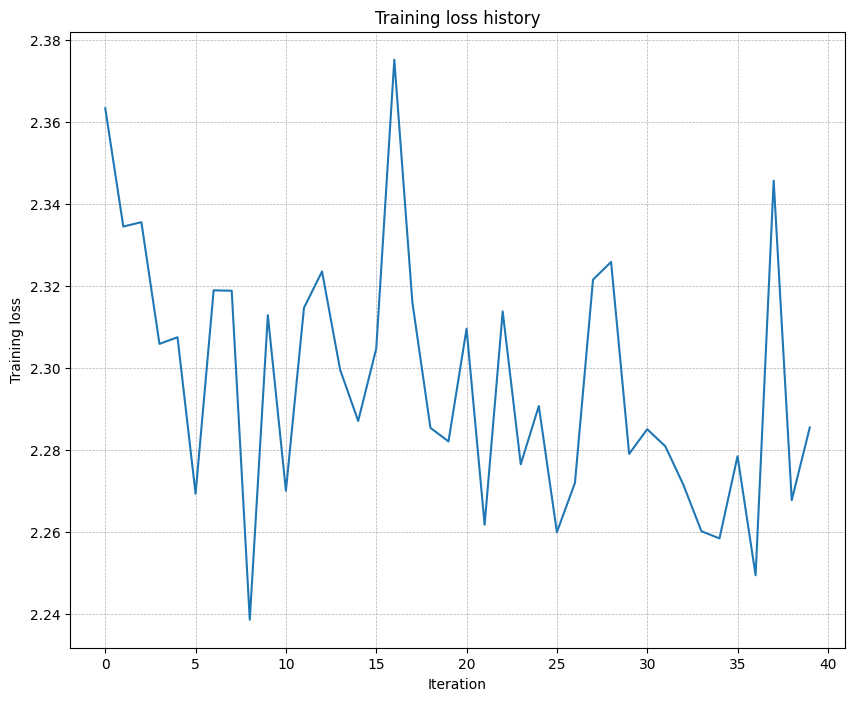

In [4]:
# TODO: Use a three-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.

num_train = 50
small_data = {
  "X_train": data["X_train"][:num_train],
  "y_train": data["y_train"][:num_train],
  "X_val": data["X_val"],
  "y_val": data["y_val"],
}

weight_scale = 1e-2   # Experiment with this!
learning_rate = 1e-4  # Experiment with this!


model = FullyConnectedNet(
    [100, 100],
    weight_scale=weight_scale,
    dtype=np.float64
)
solver = Solver(
    model,
    small_data,
    print_every=10,
    num_epochs=20,
    batch_size=25,
    update_rule="sgd",
    optim_config={"learning_rate": learning_rate},
)
solver.train()

plt.plot(solver.loss_history)
plt.title("Training loss history")
plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

现在，尝试使用一个五层网络在 50 个训练样本上过拟合，每层包含 100 个单元。同样，你需要调整学习率和权重初始化尺度，但应该能够在 20 个 epoch 内达到 100% 的训练准确率。

(Iteration 1 / 40) loss: 95.189962
(Epoch 0 / 20) train acc: 0.200000; val_acc: 0.078000
(Epoch 1 / 20) train acc: 0.160000; val_acc: 0.113000
(Epoch 2 / 20) train acc: 0.320000; val_acc: 0.123000
(Epoch 3 / 20) train acc: 0.500000; val_acc: 0.114000
(Epoch 4 / 20) train acc: 0.580000; val_acc: 0.112000
(Epoch 5 / 20) train acc: 0.800000; val_acc: 0.113000
(Iteration 11 / 40) loss: 1.053243
(Epoch 6 / 20) train acc: 0.780000; val_acc: 0.113000
(Epoch 7 / 20) train acc: 0.920000; val_acc: 0.124000
(Epoch 8 / 20) train acc: 0.960000; val_acc: 0.125000
(Epoch 9 / 20) train acc: 0.960000; val_acc: 0.125000
(Epoch 10 / 20) train acc: 0.920000; val_acc: 0.118000
(Iteration 21 / 40) loss: 0.553753
(Epoch 11 / 20) train acc: 0.960000; val_acc: 0.128000
(Epoch 12 / 20) train acc: 1.000000; val_acc: 0.130000
(Epoch 13 / 20) train acc: 1.000000; val_acc: 0.130000
(Epoch 14 / 20) train acc: 1.000000; val_acc: 0.130000
(Epoch 15 / 20) train acc: 1.000000; val_acc: 0.130000
(Iteration 31 / 40) loss:

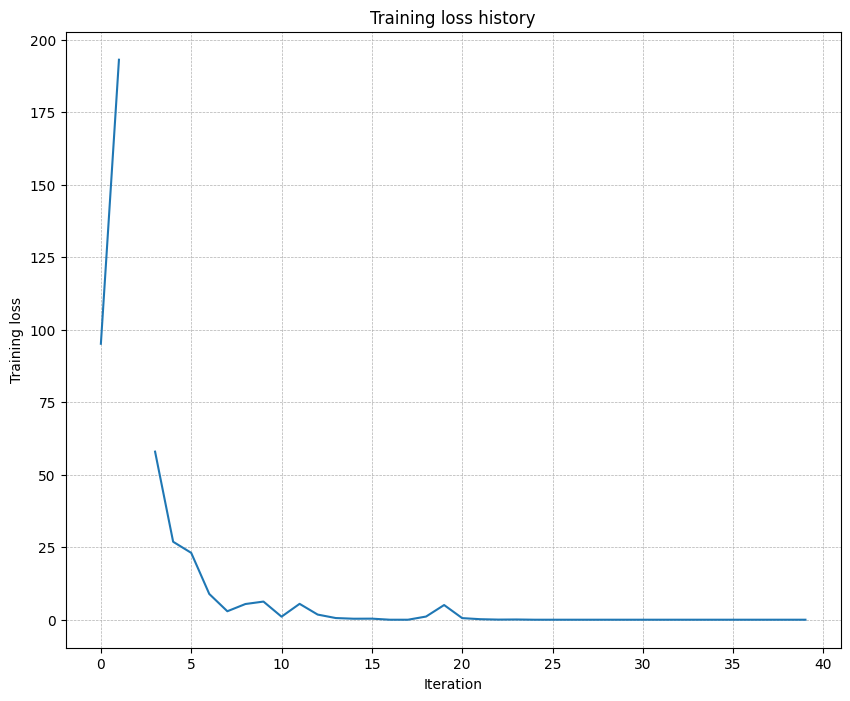

In [7]:
# TODO: Use a five-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.

num_train = 50
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

learning_rate = 1e-3 # Experiment with this!
weight_scale = 1e-1   # Experiment with this!


model = FullyConnectedNet(
    [100, 100, 100, 100],
    weight_scale=weight_scale,
    dtype=np.float64
)
solver = Solver(
    model,
    small_data,
    print_every=10,
    num_epochs=20,
    batch_size=25,
    update_rule='sgd',
    optim_config={'learning_rate': learning_rate},
)
solver.train()

plt.plot(solver.loss_history)
plt.title('Training loss history')
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

## 行内问题 1：
你是否注意到，训练三层网络和训练五层网络的难度有所不同？具体来说，根据你的实验，哪一个网络对初始化尺度更敏感？你认为原因是什么？

## 答案：
[在此填写]




# 更新规则
到目前为止，我们一直使用普通随机梯度下降（SGD）作为更新规则。更复杂的更新规则可以让深度网络更容易训练。接下来我们会实现几种最常用的更新规则，并将它们与普通 SGD 进行比较。

## SGD + 动量
带动量的随机梯度下降是一种广泛使用的更新规则，通常能让深度网络比普通随机梯度下降收敛得更快。更多信息请参阅 http://cs231n.github.io/neural-networks-3/#sgd 中的 Momentum Update 一节。

打开 `cs231n/optim.py` 文件并阅读文件顶部的文档，确保你理解其 API。在 `sgd_momentum` 函数中实现 SGD + 动量更新规则，然后运行下面的代码检查你的实现。误差应小于 `1e-8`。

In [8]:
from cs231n.optim import sgd_momentum

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
v = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {"learning_rate": 1e-3, "velocity": v}
next_w, _ = sgd_momentum(w, dw, config=config)

expected_next_w = np.asarray([
  [ 0.1406,      0.20738947,  0.27417895,  0.34096842,  0.40775789],
  [ 0.47454737,  0.54133684,  0.60812632,  0.67491579,  0.74170526],
  [ 0.80849474,  0.87528421,  0.94207368,  1.00886316,  1.07565263],
  [ 1.14244211,  1.20923158,  1.27602105,  1.34281053,  1.4096    ]])
expected_velocity = np.asarray([
  [ 0.5406,      0.55475789,  0.56891579, 0.58307368,  0.59723158],
  [ 0.61138947,  0.62554737,  0.63970526,  0.65386316,  0.66802105],
  [ 0.68217895,  0.69633684,  0.71049474,  0.72465263,  0.73881053],
  [ 0.75296842,  0.76712632,  0.78128421,  0.79544211,  0.8096    ]])

# Should see relative errors around e-8 or less
print("next_w error: ", rel_error(next_w, expected_next_w))
print("velocity error: ", rel_error(expected_velocity, config["velocity"]))

next_w error:  8.882347033505819e-09
velocity error:  4.269287743278663e-09


完成后，运行下面的代码，分别使用 SGD 和 SGD + 动量训练一个六层网络。你应该会看到 SGD + 动量更新规则收敛得更快。

Running with  sgd
(Iteration 1 / 200) loss: 2.496543
(Epoch 0 / 5) train acc: 0.126000; val_acc: 0.128000
(Iteration 11 / 200) loss: 2.278699
(Iteration 21 / 200) loss: 2.211112
(Iteration 31 / 200) loss: 2.094212
(Epoch 1 / 5) train acc: 0.213000; val_acc: 0.233000
(Iteration 41 / 200) loss: 2.188058
(Iteration 51 / 200) loss: 2.088462
(Iteration 61 / 200) loss: 2.067895
(Iteration 71 / 200) loss: 1.950550
(Epoch 2 / 5) train acc: 0.271000; val_acc: 0.270000
(Iteration 81 / 200) loss: 2.002748
(Iteration 91 / 200) loss: 1.971902
(Iteration 101 / 200) loss: 2.008380
(Iteration 111 / 200) loss: 1.959893
(Epoch 3 / 5) train acc: 0.305000; val_acc: 0.280000
(Iteration 121 / 200) loss: 1.970754
(Iteration 131 / 200) loss: 1.884831
(Iteration 141 / 200) loss: 1.936205
(Iteration 151 / 200) loss: 1.804440
(Epoch 4 / 5) train acc: 0.335000; val_acc: 0.310000
(Iteration 161 / 200) loss: 1.853750
(Iteration 171 / 200) loss: 1.698975
(Iteration 181 / 200) loss: 1.902029
(Iteration 191 / 200) los

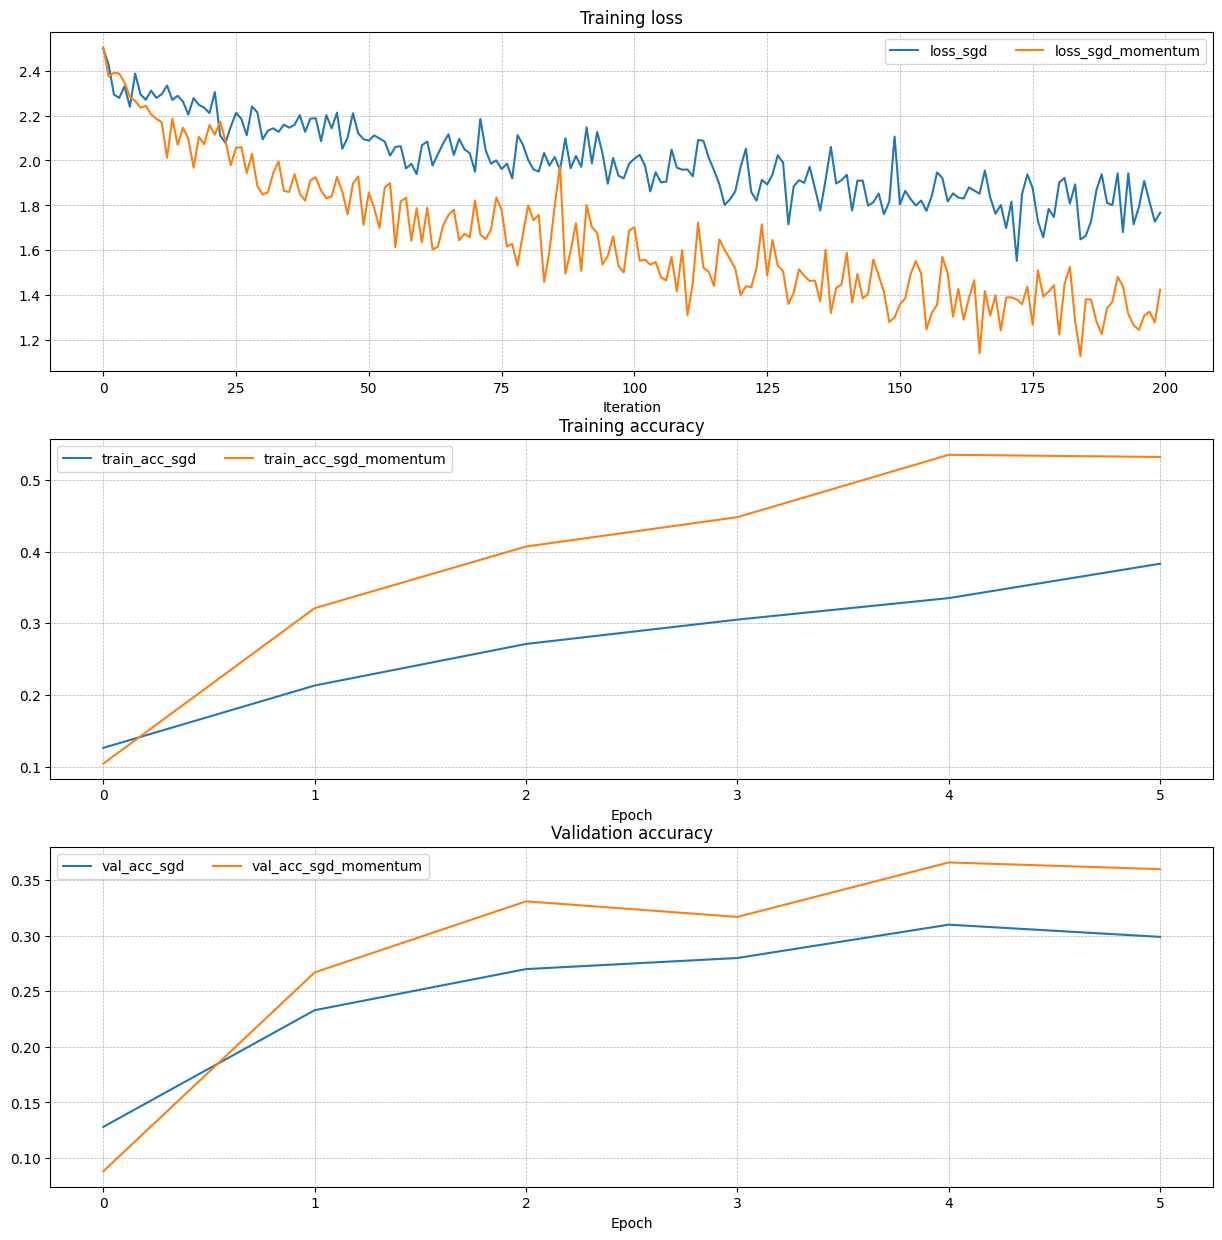

In [9]:
num_train = 4000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

solvers = {}

for update_rule in ['sgd', 'sgd_momentum']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )

    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': 5e-3},
        verbose=True,
    )
    solvers[update_rule] = solver
    solver.train()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"loss_{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"train_acc_{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"val_acc_{update_rule}")

for ax in axes:
    ax.legend(loc="best", ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()

## RMSProp 与 Adam
RMSProp [1] 和 Adam [2] 都是利用梯度二阶矩的滑动平均，为每个参数分别设置学习率的更新规则。

在 `cs231n/optim.py` 文件中，在 `rmsprop` 函数里实现 RMSProp 更新规则，并在 `adam` 函数里实现 Adam 更新规则，然后使用下面的测试检查你的实现。

**注意：**请实现_完整的_ Adam 更新规则（包括偏差修正机制），不要实现课程讲义中首先提到的简化版本。

[1] Tijmen Tieleman and Geoffrey Hinton. “Lecture 6.5-rmsprop: Divide the gradient by a running average of its recent magnitude.” COURSERA: Neural Networks for Machine Learning 4 (2012).

[2] Diederik Kingma and Jimmy Ba, “Adam: A Method for Stochastic Optimization”, ICLR 2015.

In [10]:
# Test RMSProp implementation
from cs231n.optim import rmsprop

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
cache = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'cache': cache}
next_w, _ = rmsprop(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.39223849, -0.34037513, -0.28849239, -0.23659121, -0.18467247],
  [-0.132737,   -0.08078555, -0.02881884,  0.02316247,  0.07515774],
  [ 0.12716641,  0.17918792,  0.23122175,  0.28326742,  0.33532447],
  [ 0.38739248,  0.43947102,  0.49155973,  0.54365823,  0.59576619]])
expected_cache = np.asarray([
  [ 0.5976,      0.6126277,   0.6277108,   0.64284931,  0.65804321],
  [ 0.67329252,  0.68859723,  0.70395734,  0.71937285,  0.73484377],
  [ 0.75037008,  0.7659518,   0.78158892,  0.79728144,  0.81302936],
  [ 0.82883269,  0.84469141,  0.86060554,  0.87657507,  0.8926    ]])

# You should see relative errors around e-7 or less
print('next_w error: ', rel_error(expected_next_w, next_w))
print('cache error: ', rel_error(expected_cache, config['cache']))

next_w error:  9.524687511038133e-08
cache error:  2.6477955807156126e-09


In [11]:
# Test Adam implementation
from cs231n.optim import adam

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
m = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)
v = np.linspace(0.7, 0.5, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'm': m, 'v': v, 't': 5}
next_w, _ = adam(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.40094747, -0.34836187, -0.29577703, -0.24319299, -0.19060977],
  [-0.1380274,  -0.08544591, -0.03286534,  0.01971428,  0.0722929],
  [ 0.1248705,   0.17744702,  0.23002243,  0.28259667,  0.33516969],
  [ 0.38774145,  0.44031188,  0.49288093,  0.54544852,  0.59801459]])
expected_v = np.asarray([
  [ 0.69966,     0.68908382,  0.67851319,  0.66794809,  0.65738853,],
  [ 0.64683452,  0.63628604,  0.6257431,   0.61520571,  0.60467385,],
  [ 0.59414753,  0.58362676,  0.57311152,  0.56260183,  0.55209767,],
  [ 0.54159906,  0.53110598,  0.52061845,  0.51013645,  0.49966,   ]])
expected_m = np.asarray([
  [ 0.48,        0.49947368,  0.51894737,  0.53842105,  0.55789474],
  [ 0.57736842,  0.59684211,  0.61631579,  0.63578947,  0.65526316],
  [ 0.67473684,  0.69421053,  0.71368421,  0.73315789,  0.75263158],
  [ 0.77210526,  0.79157895,  0.81105263,  0.83052632,  0.85      ]])

# You should see relative errors around e-7 or less
print('next_w error: ', rel_error(expected_next_w, next_w))
print('v error: ', rel_error(expected_v, config['v']))
print('m error: ', rel_error(expected_m, config['m']))

next_w error:  1.1395691798535431e-07
v error:  4.208314038113071e-09
m error:  4.214963193114416e-09


调试完 RMSProp 和 Adam 的实现后，运行下面的代码，使用这些新的更新规则训练一组深度网络：

Running with  adam
(Iteration 1 / 200) loss: 2.632361
(Epoch 0 / 5) train acc: 0.122000; val_acc: 0.133000
(Iteration 11 / 200) loss: 2.032235
(Iteration 21 / 200) loss: 2.002275
(Iteration 31 / 200) loss: 1.804059
(Epoch 1 / 5) train acc: 0.384000; val_acc: 0.324000
(Iteration 41 / 200) loss: 1.797411
(Iteration 51 / 200) loss: 1.895018
(Iteration 61 / 200) loss: 1.891465
(Iteration 71 / 200) loss: 1.746953
(Epoch 2 / 5) train acc: 0.422000; val_acc: 0.317000
(Iteration 81 / 200) loss: 1.463406
(Iteration 91 / 200) loss: 1.508699
(Iteration 101 / 200) loss: 1.505684
(Iteration 111 / 200) loss: 1.448677
(Epoch 3 / 5) train acc: 0.503000; val_acc: 0.348000
(Iteration 121 / 200) loss: 1.296077
(Iteration 131 / 200) loss: 1.492120
(Iteration 141 / 200) loss: 1.473794
(Iteration 151 / 200) loss: 1.041155
(Epoch 4 / 5) train acc: 0.548000; val_acc: 0.373000
(Iteration 161 / 200) loss: 1.379474
(Iteration 171 / 200) loss: 1.223897
(Iteration 181 / 200) loss: 1.171233
(Iteration 191 / 200) lo

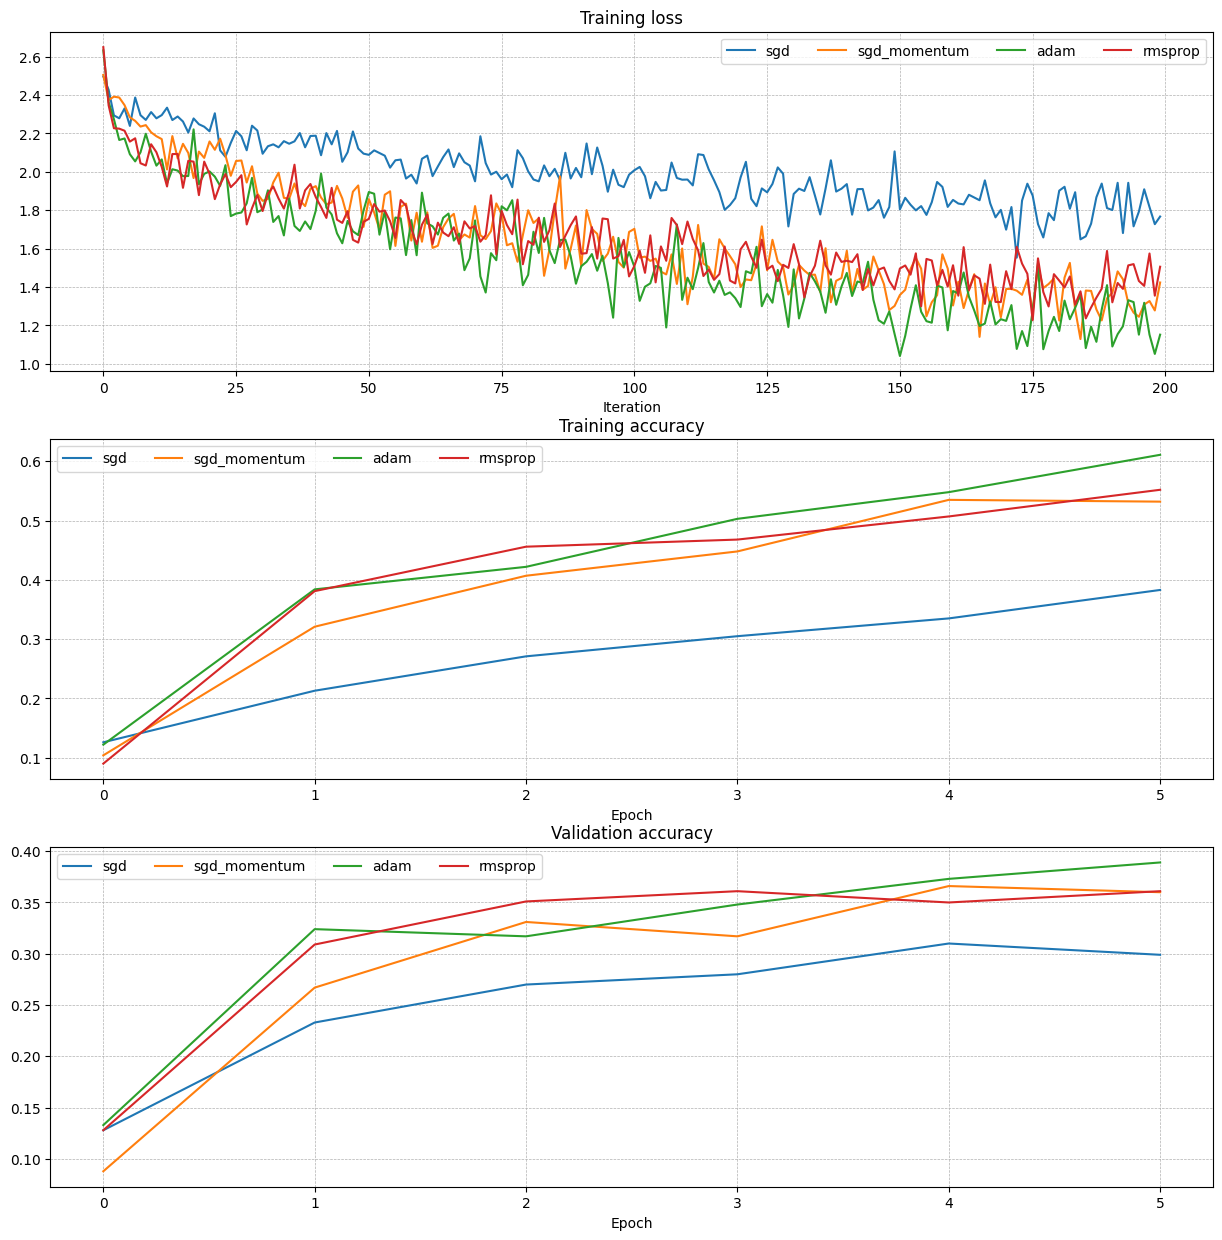

In [12]:
learning_rates = {'rmsprop': 1e-4, 'adam': 1e-3}
for update_rule in ['adam', 'rmsprop']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )
    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': learning_rates[update_rule]},
        verbose=True
    )
    solvers[update_rule] = solver
    solver.train()
    print()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"{update_rule}")

for ax in axes:
    ax.legend(loc='best', ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()

## 行内问题 2：

AdaGrad 与 Adam 一样，是一种逐参数优化方法，使用以下更新规则：

```
cache += dw**2
w += - learning_rate * dw / (np.sqrt(cache) + eps)
```

John 在使用 AdaGrad 训练网络时发现，参数更新变得非常小，网络学习得很慢。根据你对 AdaGrad 更新规则的理解，为什么更新会变得非常小？Adam 也会遇到同样的问题吗？


## 答案：
[在此填写]




# 训练一个好模型！
在 CIFAR-10 上训练你能得到的最佳全连接模型，并把最佳模型保存在 `best_model` 变量中。我们要求全连接网络在验证集上的准确率至少达到 50%。

如果仔细调参，准确率应该可以超过 55%，但这一部分并不强制要求，也不会因此获得额外分数。在下一次作业中，我们会要求你训练尽可能好的卷积神经网络；相比继续优化全连接网络，我们更希望你把精力放在卷积神经网络上。

**注意：**在下一次作业中，你将学习 Batch Normalization 和 Dropout 等技术，它们可以帮助你训练更强大的模型。

In [4]:
best_model = None

################################################################################
# TODO: Train the best FullyConnectedNet that you can on CIFAR-10. You might   #
# find batch/layer normalization and dropout useful. Store your best model in  #
# the best_model variable.                                                     #
################################################################################
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
best_model = None

model = FullyConnectedNet(
    hidden_dims=[100, 100],
    input_dim=3 * 32 * 32,
    num_classes=10,
    weight_scale=1e-2,
    reg=1e-3,
    dtype=np.float32,
)

solver = Solver(
    model,
    data,  # 使用完整训练集，不是 small_data
    update_rule="adam",
    optim_config={
        "learning_rate": 1e-3,
    },
    lr_decay=0.95,
    num_epochs=15,
    batch_size=200,
    print_every=100,
    verbose=True,
)

solver.train()

# Solver 训练结束后，model 中已经恢复了验证集表现最好的参数
best_model = model

print("Best validation accuracy:", solver.best_val_acc)


# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
################################################################################
#                              END OF YOUR CODE                                #
################################################################################

(Iteration 1 / 3675) loss: 2.352507
(Epoch 0 / 15) train acc: 0.203000; val_acc: 0.171000
(Iteration 101 / 3675) loss: 1.649059
(Iteration 201 / 3675) loss: 1.445647
(Epoch 1 / 15) train acc: 0.470000; val_acc: 0.432000
(Iteration 301 / 3675) loss: 1.606720
(Iteration 401 / 3675) loss: 1.491794
(Epoch 2 / 15) train acc: 0.472000; val_acc: 0.476000
(Iteration 501 / 3675) loss: 1.395189
(Iteration 601 / 3675) loss: 1.483091
(Iteration 701 / 3675) loss: 1.441611
(Epoch 3 / 15) train acc: 0.484000; val_acc: 0.469000
(Iteration 801 / 3675) loss: 1.446994
(Iteration 901 / 3675) loss: 1.349691
(Epoch 4 / 15) train acc: 0.521000; val_acc: 0.477000
(Iteration 1001 / 3675) loss: 1.604092
(Iteration 1101 / 3675) loss: 1.440586
(Iteration 1201 / 3675) loss: 1.424630
(Epoch 5 / 15) train acc: 0.539000; val_acc: 0.489000
(Iteration 1301 / 3675) loss: 1.322223
(Iteration 1401 / 3675) loss: 1.428824
(Epoch 6 / 15) train acc: 0.551000; val_acc: 0.505000
(Iteration 1501 / 3675) loss: 1.425931
(Iteration

# 测试你的模型！
在验证集和测试集上运行你的最佳模型。验证集和测试集准确率都应至少达到 50%。

In [5]:
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)
y_val_pred = np.argmax(best_model.loss(data['X_val']), axis=1)
print('Validation set accuracy: ', (y_val_pred == data['y_val']).mean())
print('Test set accuracy: ', (y_test_pred == data['y_test']).mean())

Validation set accuracy:  0.533
Test set accuracy:  0.518
